<a href="https://colab.research.google.com/github/guslimaa777/45419370/blob/main/aula6_classificacao_industrial_aluno.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 6 – Algoritmos de classificação aplicados ao contexto industrial

**Curso:** Machine Learning Aplicada à Indústria  
**Versão:** Aluno

## Objetivo da aula
Nesta aula, você irá executar classificadores em Scikit-learn e comparar as saídas iniciais de previsão em um problema industrial.


## 1. Importação das bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


### Registro do aluno
Explique:
- por que usamos Scikit-learn nesta aula;
- quais algoritmos de classificação serão comparados.


## 2. Carregando o dataset da aula

In [4]:
df = pd.read_csv("base_aula6_classificacao_industrial.csv")
print("Dimensões da base:", df.shape)
df.head()

Dimensões da base: (320, 17)


,linha_producao,turno,equipamento_monitorado,produto_quimico,status_sensor,temperatura_processo_c,pressao_linha_bar,vazao_setpoint_l_min,vazao_real_l_min,erro_vazao_pct,vibracao_mm_s,tempo_resposta_seg,consumo_energia_kwh,horas_operacao,umidade_ambiente_pct,ph_produto,condicao_operacional
0,Linha_C,Manhã,Bomba,Ácido,Instável,28.10,6.60,97.14,92.95,-4.31,3.20,3.72,90.32,1300,51.31,7.48,Normal
1,Linha_A,Tarde,Válvula,Ácido,OK,45.20,6.48,112.18,116.42,3.78,0.20,2.94,103.86,2241,43.56,7.72,Normal
2,Linha_A,Manhã,Trocador,Aditivo,OK,41.15,5.22,110.55,114.26,3.36,3.00,3.32,126.09,1622,56.64,5.75,Normal
3,Linha_A,Manhã,Válvula,Aditivo,Instável,57.56,3.51,96.73,89.59,-7.38,5.42,4.33,133.29,2459,63.29,5.84,Alerta
4,Linha_A,Noite,Trocador,Ácido,OK,44.19,5.69,108.31,122.80,13.38,2.31,2.39,161.42,3059,64.17,5.67,Normal


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
linha_producao,320,4,Linha_B,103,NaN,NaN,NaN,NaN,NaN,NaN,NaN
turno,320,3,Noite,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
equipamento_monitorado,320,4,Bomba,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
produto_quimico,320,4,Solvente,99,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status_sensor,320,3,OK,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperatura_processo_c,320.0,NaN,NaN,NaN,42.988844,8.655823,22.08,37.1825,42.685,48.2625,65.29
pressao_linha_bar,320.0,NaN,NaN,NaN,5.88425,1.139438,3.07,5.1475,5.9,6.66,9.24
vazao_setpoint_l_min,320.0,NaN,NaN,NaN,99.0205,14.135427,53.91,89.7875,98.87,108.19,135.71
vazao_real_l_min,320.0,NaN,NaN,NaN,98.218031,16.500545,49.44,86.955,97.825,108.62,142.4
erro_vazao_pct,320.0,NaN,NaN,NaN,-0.931656,7.213631,-19.14,-5.785,-0.58,4.125,19.18


>"Como estão distribuídas as diferentes condições operacionais do processo industrial e existe algum cenário que ocorre com maior frequência?"


### Vamos analisar a variavel
>***`condicao_operacional` ***

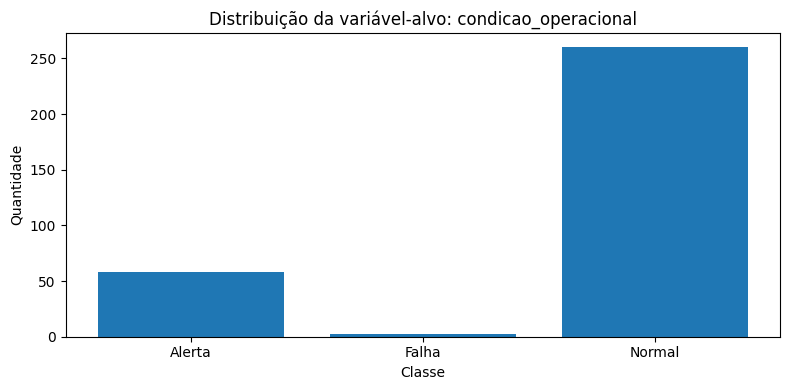

In [6]:
counts = df["condicao_operacional"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(counts.index, counts.values)
plt.title("Distribuição da variável-alvo: condicao_operacional")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

### Reflexão
- Qual é a variável-alvo da aula?
- Quais são as classes presentes?


## 3. Preparação dos dados: X e y

### Pergunta de negócio

>"Podemos prever a condição operacional de um processo industrial com base nos dados de sensores e nas características de operação?"

In [7]:
# X = variáveis preditoras
X = df.drop(columns=["condicao_operacional"])

# y = variável-alvo
y = df["condicao_operacional"]

print("Dimnesão de X:", X.shape)
print("Dimensão de y:", y.shape)
display(X.head())
display(y.head())

Dimnesão de X: (320, 16)
Dimensão de y: (320,)


,linha_producao,turno,equipamento_monitorado,produto_quimico,status_sensor,temperatura_processo_c,pressao_linha_bar,vazao_setpoint_l_min,vazao_real_l_min,erro_vazao_pct,vibracao_mm_s,tempo_resposta_seg,consumo_energia_kwh,horas_operacao,umidade_ambiente_pct,ph_produto
0,Linha_C,Manhã,Bomba,Ácido,Instável,28.10,6.60,97.14,92.95,-4.31,3.20,3.72,90.32,1300,51.31,7.48
1,Linha_A,Tarde,Válvula,Ácido,OK,45.20,6.48,112.18,116.42,3.78,0.20,2.94,103.86,2241,43.56,7.72
2,Linha_A,Manhã,Trocador,Aditivo,OK,41.15,5.22,110.55,114.26,3.36,3.00,3.32,126.09,1622,56.64,5.75
3,Linha_A,Manhã,Válvula,Aditivo,Instável,57.56,3.51,96.73,89.59,-7.38,5.42,4.33,133.29,2459,63.29,5.84
4,Linha_A,Noite,Trocador,Ácido,OK,44.19,5.69,108.31,122.80,13.38,2.31,2.39,161.42,3059,64.17,5.67


,condicao_operacional
0,Normal
1,Normal
2,Normal
3,Alerta
4,Normal


### Reflexão
- O que representa `X`?
- O que representa `y`?
- Por que a variável-alvo não pode ficar dentro de `X`?


In [8]:
colunas_numericas = X.select_dtypes(include=["number"]).columns.tolist()
colunas_categoricas = X.select_dtypes(include=["object"]).columns.tolist()

print("Colunas numéricas:")
print(colunas_numericas)
print("\nColunas categóricas:")
print(colunas_categoricas)

Colunas numéricas:
['temperatura_processo_c', 'pressao_linha_bar', 'vazao_setpoint_l_min', 'vazao_real_l_min', 'erro_vazao_pct', 'vibracao_mm_s', 'tempo_resposta_seg', 'consumo_energia_kwh', 'horas_operacao', 'umidade_ambiente_pct', 'ph_produto']

Colunas categóricas:
['linha_producao', 'turno', 'equipamento_monitorado', 'produto_quimico', 'status_sensor']


## 4. Preparação do preprocessador

In [10]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler())
        ]), colunas_numericas),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), colunas_categoricas)
    ]
)

print("Pré-processador criado com sucesso.")

Pré-processador criado com sucesso.


### Reflexão
- Por que as colunas numéricas precisam de padronização?
- Por que as colunas categóricas precisam de codificação?


## 5. Divisão da base em treino e validação

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Formato/Dimensoes de X_train:", X_train.shape)
print("Formato/Dimensoes de X_val:", X_val.shape)
print("Formato/Dimensoes de y_train:", y_train.shape)
print("Formato/Dimensoes de y_val:", y_val.shape)

Formato/Dimensoes de X_train: (240, 16)
Formato/Dimensoes de X_val: (80, 16)
Formato/Dimensoes de y_train: (240,)
Formato/Dimensoes de y_val: (80,)


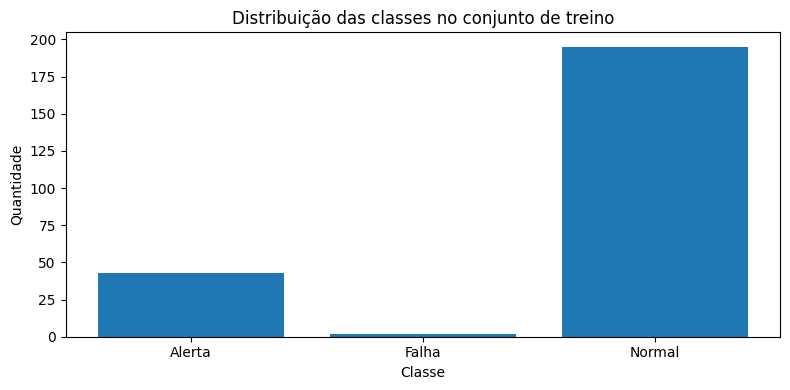

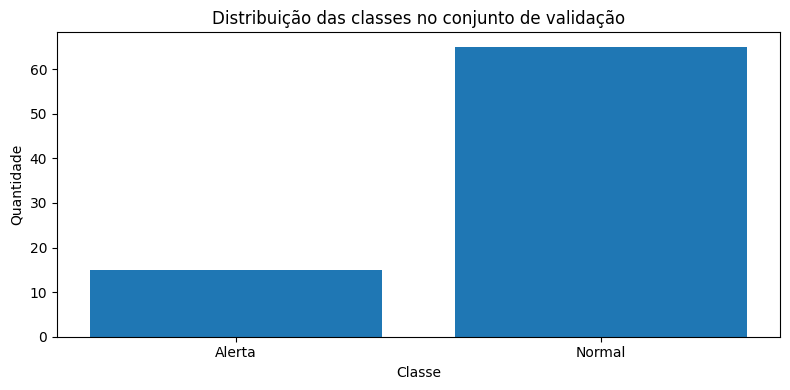

In [12]:

import matplotlib.pyplot as plt

# 1. Correção no cálculo das frequências das classes:
train_counts = y_train.value_counts().sort_index()
val_counts = y_val.value_counts().sort_index()

# 2. Gráfico do conjunto de treino:
plt.figure(figsize=(8, 4))
plt.bar(train_counts.index, train_counts.values)
plt.title("Distribuição das classes no conjunto de treino")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

# 3. Gráfico do conjunto de validação:
plt.figure(figsize=(8, 4))
plt.bar(val_counts.index, val_counts.values)
plt.title("Distribuição das classes no conjunto de validação")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

### Reflexão
- Para que serve o conjunto de treino?
- Para que serve o conjunto de validação?


## 6. Classificador 1 – Árvore de Decisão

In [13]:
from sklearn.tree import DecisionTreeClassifier

modelo_dt = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", DecisionTreeClassifier(max_depth=5, random_state=42))
])

modelo_dt.fit(X_train, y_train)
pred_dt = modelo_dt.predict(X_val)

acc_dt = accuracy_score(y_val, pred_dt)
print("Acurácia - Árvore de Decisão:", round(acc_dt, 4))
print(classification_report(y_val, pred_dt))

Acurácia - Árvore de Decisão: 0.8875
              precision    recall  f1-score   support

      Alerta       0.75      0.60      0.67        15
      Normal       0.91      0.95      0.93        65

    accuracy                           0.89        80
   macro avg       0.83      0.78      0.80        80
weighted avg       0.88      0.89      0.88        80



### Aplicar matriz de confusão

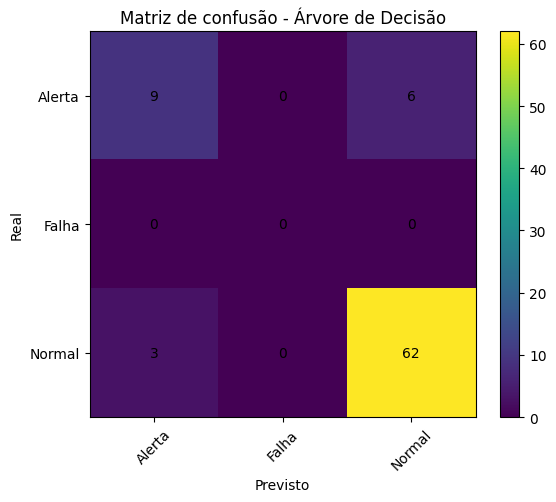

In [14]:
labels = sorted(y.unique())
cm = confusion_matrix(y_val, pred_dt, labels=labels)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Matriz de confusão - Árvore de Decisão")
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

In [15]:
print("=== EXPLICAÇÃO DA MATRIZ DE CONFUSÃO - ÁRVORE DE DECISÃO ===\n")

print(f"1. REAL: ALERTA | PREVISTO: ALERTA = {cm[0, 0]}")
print(f"   * O modelo identificou corretamente {cm[0, 0]} casos que realmente eram ALERTA.\n")

print(f"2. REAL: ALERTA | PREVISTO: FALHA = {cm[0, 1]}")
print(f"   * {cm[0, 1]} caso(s) que era(m) ALERTA foi(ram) classificado(s) pelo modelo como FALHA.\n")

print(f"3. REAL: ALERTA | PREVISTO: NORMAL = {cm[0, 2]}")
print(f"   * {cm[0, 2]} caso(s) que realmente era(m) ALERTA foi(ram) classificado(s) incorretamente como NORMAL.")
print(f"   * Este é um resultado preocupante, pois o modelo deixou de identificar esses alertas.\n")

print(f"4. REAL: FALHA | PREVISTO: ALERTA = {cm[1, 0]}")
print(f"   * {cm[1, 0]} caso(s) que realmente era(m) FALHA foi(ram) classificado(s) como ALERTA.\n")

print(f"5. REAL: FALHA | PREVISTO: FALHA = {cm[1, 1]}")
print(f"   * O modelo identificou corretamente {cm[1, 1]} caso(s) de FALHA.")
print("    * Se o valor for 0, significa que nenhum caso de FALHA foi identificado corretamente.\n")

print(f"6. REAL: FALHA | PREVISTO: NORMAL = {cm[1, 2]}")
print(f"   * {cm[1, 2]} caso(s) de FALHA foi(ram) classificado(s) como NORMAL.\n")

print(f"7. REAL: NORMAL | PREVISTO: ALERTA = {cm[2, 0]}")
print(f"   * {cm[2, 0]} caso(s) que realmente era(m) NORMAL foi(ram) classificado(s) incorretamente como ALERTA.\n")

print(f"8. REAL: NORMAL | PREVISTO: FALHA = {cm[2, 1]}")
print(f"   * {cm[2, 1]} caso(s) que realmente era(m) NORMAL foi(ram) classificado(s) como FALHA.\n")

print(f"9. REAL: NORMAL | PREVISTO: NORMAL = {cm[2, 2]}")
print(f"   * O modelo identificou corretamente {cm[2, 2]} casos que realmente eram NORMAL.\n")


print("=== RESUMO ===")

total = cm.sum()

acertos_alerta = cm[0, 0]
erros_alerta = cm[0, 1] + cm[0, 2]

acertos_falha = cm[1, 1]

acertos_normal = cm[2, 2]
erros_normal = cm[2, 0] + cm[2, 1]

print(f"Total de casos avaliados: {total}")
print(f"Acertos em ALERTA: {acertos_alerta}")
print(f"Alertas não identificados: {erros_alerta}")
print(f"Acertos em FALHA: {acertos_falha}")
print(f"Acertos em NORMAL: {acertos_normal}")
print(f"Erros ao classificar NORMAL: {erros_normal}")


print("\nConclusão:")

if acertos_normal > acertos_alerta:
    print("A Árvore de Decisão foi muito eficiente para identificar a classe NORMAL,")
    print("mas apresentou alguma dificuldade para identificar casos de ALERTA.")

print(f"Dos {cm[0, :].sum()} casos reais de ALERTA, "
      f"{cm[0, 0]} foram identificados corretamente.")

=== EXPLICAÇÃO DA MATRIZ DE CONFUSÃO - ÁRVORE DE DECISÃO ===

1. REAL: ALERTA | PREVISTO: ALERTA = 9
   * O modelo identificou corretamente 9 casos que realmente eram ALERTA.

2. REAL: ALERTA | PREVISTO: FALHA = 0
   * 0 caso(s) que era(m) ALERTA foi(ram) classificado(s) pelo modelo como FALHA.

3. REAL: ALERTA | PREVISTO: NORMAL = 6
   * 6 caso(s) que realmente era(m) ALERTA foi(ram) classificado(s) incorretamente como NORMAL.
   * Este é um resultado preocupante, pois o modelo deixou de identificar esses alertas.

4. REAL: FALHA | PREVISTO: ALERTA = 0
   * 0 caso(s) que realmente era(m) FALHA foi(ram) classificado(s) como ALERTA.

5. REAL: FALHA | PREVISTO: FALHA = 0
   * O modelo identificou corretamente 0 caso(s) de FALHA.
    * Se o valor for 0, significa que nenhum caso de FALHA foi identificado corretamente.

6. REAL: FALHA | PREVISTO: NORMAL = 0
   * 0 caso(s) de FALHA foi(ram) classificado(s) como NORMAL.

7. REAL: NORMAL | PREVISTO: ALERTA = 3
   * 3 caso(s) que realmente era

### Análise
- Qual foi a acurácia da Árvore de Decisão?
- Em quais classes ela parece acertar mais?


## 7. Classificador 2 – Random Forest

In [22]:
modelo_rf = Pipeline([
    ("preprocessamento", preprocessador),
    ("modelo", RandomForestClassifier(
        n_estimators=150,
        max_depth=7,
        random_state=42
    ))
])

modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_val)

acc_rf = accuracy_score(y_val, pred_rf)

print("Acurácia - Random Forest:", round(acc_rf, 4))
print(classification_report(y_val, pred_rf))

Acurácia - Random Forest: 0.85
              precision    recall  f1-score   support

      Alerta       1.00      0.20      0.33        15
      Normal       0.84      1.00      0.92        65

    accuracy                           0.85        80
   macro avg       0.92      0.60      0.62        80
weighted avg       0.87      0.85      0.81        80



### Aplicar matriz de confusão

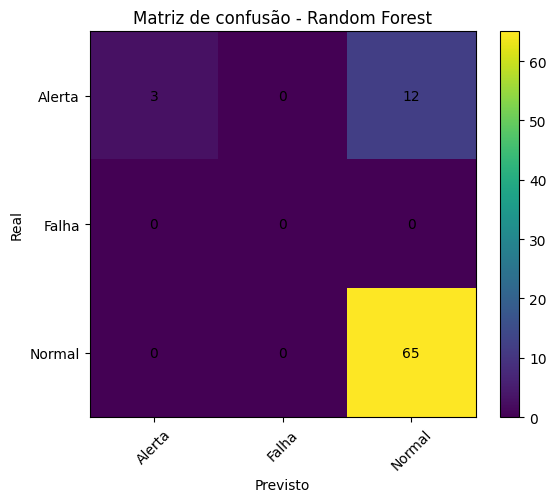

In [23]:
labels = sorted(y.unique())
cm = confusion_matrix(y_val, pred_rf, labels=labels)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Matriz de confusão - Random Forest")
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

In [30]:
print("=== EXPLICAÇÃO DA MATRIZ DE CONFUSÃO - RANDOM FOREST ===\n")

print(f"1. REAL: ALERTA | PREVISTO: ALERTA = {cm[0, 0]}")
print(f"   * O modelo identificou corretamente {cm[0, 0]} casos que realmente eram ALERTA.\n")

print(f"2. REAL: ALERTA | PREVISTO: FALHA = {cm[0, 1]}")
print(f"   * {cm[0, 1]} caso(s) que era(m) ALERTA foi(ram) classificado(s) pelo modelo como FALHA.\n")

print(f"3. REAL: ALERTA | PREVISTO: NORMAL = {cm[0, 2]}")
print(f"   * {cm[0, 2]} caso(s) que realmente era(m) ALERTA foi(ram) classificado(s) incorretamente como NORMAL.")
print(f"   * Este é um resultado preocupante, pois o modelo deixou de identificar esses alertas.\n")

print(f"4. REAL: FALHA | PREVISTO: ALERTA = {cm[1, 0]}")
print(f"   * {cm[1, 0]} caso(s) que realmente era(m) FALHA foi(ram) classificado(s) como ALERTA.\n")

print(f"5. REAL: FALHA | PREVISTO: FALHA = {cm[1, 1]}")
print(f"   * O modelo identificou corretamente {cm[1, 1]} caso(s) de FALHA.")
print("   * Se o valor for 0, significa que nenhum caso de FALHA foi identificado corretamente.\n")

print(f"6. REAL: FALHA | PREVISTO: NORMAL = {cm[1, 2]}")
print(f"   * {cm[1, 2]} caso(s) de FALHA foi(ram) classificado(s) como NORMAL.\n")

print(f"7. REAL: NORMAL | PREVISTO: ALERTA = {cm[2, 0]}")
print(f"   * {cm[2, 0]} caso(s) que realmente era(m) NORMAL foi(ram) classificado(s) incorretamente como ALERTA.\n")

print(f"8. REAL: NORMAL | PREVISTO: FALHA = {cm[2, 1]}")
print(f"   * {cm[2, 1]} caso(s) que realmente era(m) NORMAL foi(ram) classificado(s) como FALHA.\n")

print(f"9. REAL: NORMAL | PREVISTO: NORMAL = {cm[2, 2]}")
print(f"   * O modelo identificou corretamente {cm[2, 2]} casos que realmente eram NORMAL.\n")

print("=== RESUMO ===")

total = cm.sum()

acertos_alerta = cm[0, 0]
erros_alerta = cm[0, 1] + cm[0, 2]

acertos_falha = cm[1, 1]

acertos_normal = cm[2, 2]
erros_normal = cm[2, 0] + cm[2, 1]

print(f"Total de casos avaliados: {total}")
print(f"Acertos em ALERTA: {acertos_alerta}")
print(f"Alertas não identificados: {erros_alerta}")
print(f"Acertos em FALHA: {acertos_falha}")
print(f"Acertos em NORMAL: {acertos_normal}")
print(f"Erros ao classificar NORMAL: {erros_normal}")


print("\nConclusão:")

if acertos_normal > acertos_alerta:
    print("O Random Forest foi muito eficiente para identificar a classe NORMAL,")
    print("mas apresentou maior dificuldade para identificar casos de ALERTA.")

print(f"Dos {cm[0, :].sum()} casos reais de ALERTA, "
      f"apenas {acertos_alerta} foram identificados corretamente.")

=== EXPLICAÇÃO DA MATRIZ DE CONFUSÃO - RANDOM FOREST ===

1. REAL: ALERTA | PREVISTO: ALERTA = 7
   * O modelo identificou corretamente 7 casos que realmente eram ALERTA.

2. REAL: ALERTA | PREVISTO: FALHA = 0
   * 0 caso(s) que era(m) ALERTA foi(ram) classificado(s) pelo modelo como FALHA.

3. REAL: ALERTA | PREVISTO: NORMAL = 8
   * 8 caso(s) que realmente era(m) ALERTA foi(ram) classificado(s) incorretamente como NORMAL.
   * Este é um resultado preocupante, pois o modelo deixou de identificar esses alertas.

4. REAL: FALHA | PREVISTO: ALERTA = 0
   * 0 caso(s) que realmente era(m) FALHA foi(ram) classificado(s) como ALERTA.

5. REAL: FALHA | PREVISTO: FALHA = 0
   * O modelo identificou corretamente 0 caso(s) de FALHA.
   * Se o valor for 0, significa que nenhum caso de FALHA foi identificado corretamente.

6. REAL: FALHA | PREVISTO: NORMAL = 0
   * 0 caso(s) de FALHA foi(ram) classificado(s) como NORMAL.

7. REAL: NORMAL | PREVISTO: ALERTA = 11
   * 11 caso(s) que realmente era(m)

### Análise
- O Random Forest foi melhor ou pior que a Árvore de Decisão?
- O que você observou na matriz de confusão?


## 8. Classificador 3 – Naïve Bayes

### Pergunta de negócio

>"É possível identificar automaticamente a condição operacional de um processo industrial a partir dos dados dos sensores, apoiando a detecção antecipada de situações de atenção?"

In [28]:
# Para o GaussianNB, precisamos transformar os dados antes do treino
X_train_transf = preprocessador.fit_transform(X_train)
X_val_transf = preprocessador.transform(X_val)

# Se o resultado vier esparso, converter para array denso
if hasattr(X_train_transf, "toarray"):
    X_train_transf = X_train_transf.toarray()

if hasattr(X_val_transf, "toarray"):
    X_val_transf = X_val_transf.toarray()

modelo_nb = GaussianNB()
modelo_nb.fit(X_train_transf, y_train)
pred_nb = modelo_nb.predict(X_val_transf)

acc_nb = accuracy_score(y_val, pred_nb)
print("Acurácia - Naïve Bayes:", round(acc_nb, 4))
print(classification_report(y_val, pred_nb))

Acurácia - Naïve Bayes: 0.7625
              precision    recall  f1-score   support

      Alerta       0.39      0.47      0.42        15
      Normal       0.87      0.83      0.85        65

    accuracy                           0.76        80
   macro avg       0.63      0.65      0.64        80
weighted avg       0.78      0.76      0.77        80



###Matriz de confusão

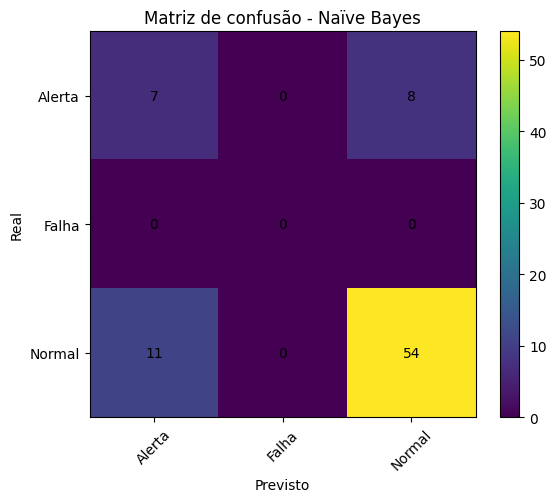

In [29]:
labels = sorted(y.unique())
cm = confusion_matrix(y_val, pred_nb, labels=labels)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Matriz de confusão - Naïve Bayes")
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()

In [31]:
print("=== EXPLICAÇÃO DA MATRIZ DE CONFUSÃO - NAÏVE BAYES ===\n")

print(f"1. REAL: ALERTA | PREVISTO: ALERTA = {cm[0, 0]}")
print(f"   * O modelo identificou corretamente {cm[0, 0]} casos que realmente eram ALERTA.\n")

print(f"2. REAL: ALERTA | PREVISTO: FALHA = {cm[0, 1]}")
print(f"   * {cm[0, 1]} caso(s) que era(m) ALERTA foi(ram) classificado(s) pelo modelo como FALHA.\n")

print(f"3. REAL: ALERTA | PREVISTO: NORMAL = {cm[0, 2]}")
print(f"   * {cm[0, 2]} caso(s) que realmente era(m) ALERTA foi(ram) classificado(s) incorretamente como NORMAL.")
print("    * Este é um resultado preocupante, pois o modelo deixou de identificar esses alertas.\n")

print(f"4. REAL: FALHA | PREVISTO: ALERTA = {cm[1, 0]}")
print(f"   * {cm[1, 0]} caso(s) que realmente era(m) FALHA foi(ram) classificado(s) como ALERTA.\n")

print(f"5. REAL: FALHA | PREVISTO: FALHA = {cm[1, 1]}")
print(f"   * Não houve nenhum registro de FALHA identificado corretamente: {cm[1, 1]}.")
print("    * Isso ocorre porque não existem exemplos da classe FALHA nesse conjunto de teste.\n")

print(f"6. REAL: FALHA | PREVISTO: NORMAL = {cm[1, 2]}")
print(f"   * {cm[1, 2]} caso(s) de FALHA foi(ram) classificado(s) como NORMAL.\n")

print(f"7. REAL: NORMAL | PREVISTO: ALERTA = {cm[2, 0]}")
print(f"   * {cm[2, 0]} caso(s) que realmente era(m) NORMAL foi(ram) classificado(s) incorretamente como ALERTA.\n")

print(f"8. REAL: NORMAL | PREVISTO: FALHA = {cm[2, 1]}")
print(f"   * {cm[2, 1]} caso(s) que realmente era(m) NORMAL foi(ram) classificado(s) como FALHA.\n")

print(f"9. REAL: NORMAL | PREVISTO: NORMAL = {cm[2, 2]}")
print(f"   * O modelo identificou corretamente {cm[2, 2]} casos que realmente eram NORMAL.\n")


print("=== RESUMO ===")

total = cm.sum()

acertos_alerta = cm[0, 0]
alertas_nao_identificados = cm[0, 1] + cm[0, 2]

acertos_falha = cm[1, 1]

acertos_normal = cm[2, 2]
erros_normal = cm[2, 0] + cm[2, 1]

print(f"Total de casos avaliados: {total}")
print(f"Acertos em ALERTA: {acertos_alerta}")
print(f"Alertas não identificados: {alertas_nao_identificados}")
print(f"Acertos em FALHA: {acertos_falha}")
print(f"Acertos em NORMAL: {acertos_normal}")
print(f"Erros ao classificar NORMAL: {erros_normal}")


print("\nConclusão:")

print("O Naïve Bayes apresentou dificuldade para identificar corretamente")
print("alguns casos de ALERTA e também classificou alguns casos NORMAL como ALERTA.")

total_alertas = cm[0, :].sum()

print(f"Dos {total_alertas} casos reais de ALERTA, "
      f"apenas {acertos_alerta} foram identificados corretamente.")

=== EXPLICAÇÃO DA MATRIZ DE CONFUSÃO - NAÏVE BAYES ===

1. REAL: ALERTA | PREVISTO: ALERTA = 7
   * O modelo identificou corretamente 7 casos que realmente eram ALERTA.

2. REAL: ALERTA | PREVISTO: FALHA = 0
   * 0 caso(s) que era(m) ALERTA foi(ram) classificado(s) pelo modelo como FALHA.

3. REAL: ALERTA | PREVISTO: NORMAL = 8
   * 8 caso(s) que realmente era(m) ALERTA foi(ram) classificado(s) incorretamente como NORMAL.
    * Este é um resultado preocupante, pois o modelo deixou de identificar esses alertas.

4. REAL: FALHA | PREVISTO: ALERTA = 0
   * 0 caso(s) que realmente era(m) FALHA foi(ram) classificado(s) como ALERTA.

5. REAL: FALHA | PREVISTO: FALHA = 0
   * Não houve nenhum registro de FALHA identificado corretamente: 0.
    * Isso ocorre porque não existem exemplos da classe FALHA nesse conjunto de teste.

6. REAL: FALHA | PREVISTO: NORMAL = 0
   * 0 caso(s) de FALHA foi(ram) classificado(s) como NORMAL.

7. REAL: NORMAL | PREVISTO: ALERTA = 11
   * 11 caso(s) que realment

### Análise
- Como foi o desempenho do Naïve Bayes?
- O que mudou em relação aos outros modelos?


## 9. Comparação entre os classificadores

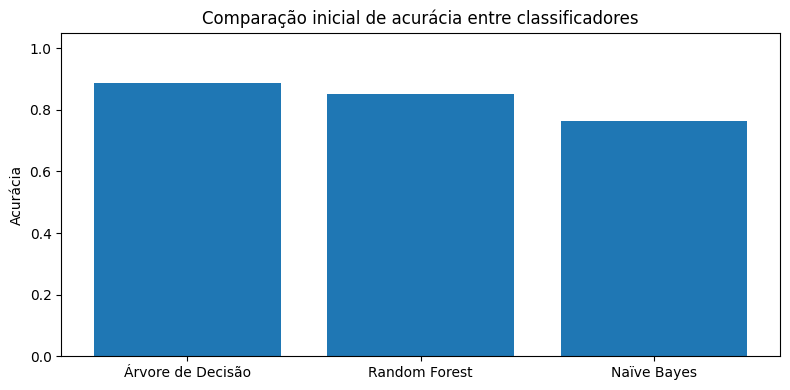

In [37]:
metricas = {
    "Árvore de Decisão": acc_dt,
    "Random Forest": acc_rf,
    "Naïve Bayes": acc_nb
}

plt.figure(figsize=(8,4))
plt.bar(metricas.keys(), metricas.values())
plt.title("Comparação inicial de acurácia entre classificadores")
plt.ylabel("Acurácia")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 10. Saídas iniciais de predição

In [42]:
resultado_previsoes = X_val.copy()
resultado_previsoes["real"] = y_val.values
resultado_previsoes["pred_arvore"] = pred_dt
resultado_previsoes["pred_random_forest"] = pred_rf
resultado_previsoes["pred_naive_bayes"] = pred_nb

display(resultado_previsoes.drop(columns=["real", "pred_arvore", "pred_random_forest", "pred_naive_bayes"]).head(10))
display(resultado_previsoes[["real", "pred_arvore", "pred_random_forest", "pred_naive_bayes"]].head(10))

,linha_producao,turno,equipamento_monitorado,produto_quimico,status_sensor,temperatura_processo_c,pressao_linha_bar,vazao_setpoint_l_min,vazao_real_l_min,erro_vazao_pct,vibracao_mm_s,tempo_resposta_seg,consumo_energia_kwh,horas_operacao,umidade_ambiente_pct,ph_produto
318,Linha_C,Tarde,Bomba,Ácido,Instável,39.65,5.59,76.58,75.38,-1.57,3.57,3.20,124.33,2283,31.80,8.54
317,Linha_D,Tarde,Trocador,Ácido,OK,37.20,5.41,113.35,120.18,6.03,4.39,2.48,140.82,2526,69.72,6.09
127,Linha_B,Noite,Trocador,Solvente,OK,35.48,5.29,99.40,95.99,-3.43,1.81,2.71,107.22,2368,49.88,7.71
99,Linha_A,Noite,Sensor,Aditivo,OK,30.17,5.38,92.62,94.58,2.12,2.79,2.66,127.31,1154,64.02,8.54
75,Linha_B,Manhã,Trocador,Ácido,Instável,46.47,6.71,78.58,86.25,9.76,2.30,2.56,135.33,2886,40.90,8.74
47,Linha_A,Manhã,Sensor,Base,OK,35.32,3.89,101.27,116.44,14.98,2.00,2.26,106.53,1552,73.41,6.64
274,Linha_A,Tarde,Bomba,Aditivo,OK,33.61,6.10,115.23,109.68,-4.82,1.63,3.29,114.28,1579,48.56,4.78
81,Linha_C,Tarde,Bomba,Solvente,Instável,41.75,5.83,79.38,72.36,-8.84,4.99,4.44,168.26,2585,66.68,7.02
120,Linha_D,Manhã,Bomba,Ácido,OK,45.74,7.65,96.87,93.00,-4.00,0.97,1.98,148.56,1738,78.73,7.08
207,Linha_D,Noite,Trocador,Base,Instável,41.97,5.13,92.46,85.44,-7.59,3.35,4.51,125.31,1902,73.46,7.43


,real,pred_arvore,pred_random_forest,pred_naive_bayes
318,Normal,Normal,Normal,Normal
317,Normal,Normal,Normal,Normal
127,Normal,Normal,Normal,Normal
99,Normal,Normal,Normal,Normal
75,Normal,Normal,Normal,Alerta
47,Normal,Normal,Normal,Normal
274,Normal,Normal,Normal,Normal
81,Alerta,Alerta,Normal,Alerta
120,Normal,Alerta,Normal,Normal
207,Alerta,Alerta,Normal,Alerta


## Evidência de aprendizagem esperada
- notebook com treinamento dos classificadores;
- saídas iniciais de previsão;
- comparação preliminar entre os modelos.


### ***Extra***
> Espaço IA Generativa

In [43]:
!pip install -q groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 10.5 MB/s eta 0:00:00


In [44]:
from groq import Groq
from google.colab import files
import base64

from google.colab import userdata
groq_api_key= userdata.get('groq.API')

client = Groq(api_key=groq_api_key)

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(
            image_file.read()
        ).decode("utf-8")

In [45]:
arquivo = files.upload()
nome_arquivo = list(arquivo.keys())[0]
print("Arquivo selecionado:", nome_arquivo)
base64_image = encode_image(nome_arquivo)

Saving Captura de tela 2026-09-19 173807.png to Captura de tela 2026-09-19 173807.png
Arquivo selecionado: Captura de tela 2026-09-19 173807.png


In [46]:
prompt= input("Digite aqui sua pergunta===>")
display(prompt)

Digite aqui sua pergunta===>me explique mais sobre esse grafico?


'me explique mais sobre esse grafico?'

In [50]:

response = client.chat.completions.create(
    model="qwen/qwen3.8-27b",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": f"{prompt}"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}"
                    }
                }
            ]
        }
    ],
    temperature=0,

)

print(response.choices[0].message.content)

Claro! Vamos analisar essa **Matriz de Confusão** do modelo **Naive Bayes** em detalhes.

---

### 📊 O que é uma Matriz de Confusão?

É uma tabela que mostra o desempenho de um modelo de classificação, comparando as **previsões feitas pelo modelo** com os **valores reais (ground truth)**.

- **Linhas (eixo Y)**: Classes **Reais** (o que realmente aconteceu).
- **Colunas (eixo X)**: Classes **Previstas** (o que o modelo previu).
- **Células**: Número de amostras que caíram naquela combinação (real vs. previsto).

---

## 🔍 Análise da sua Matriz

Aqui está a matriz completa:

| Real \ Previsto | Alerta | Falha | Normal |
|------------------|--------|-------|--------|
| **Alerta**       |   7    |   0   |   8    |
| **Falha**        |   0    |   0   |   0    |
| **Normal**       |  11    |   0   |  54    |

---

## ✅ Interpretação Célula por Célula

### 1. **Alerta Real → Alerta Previsto = 7**
→ O modelo acertou: previu "Alerta" quando era realmente "Alerta".  
✅ **Verdadeiro Positivo (TP

### Reflexão final
- Qual classificador teve melhor desempenho inicial?
- Todos os modelos erraram da mesma forma?
- Qual deles parece mais adequado para o problema industrial desta aula?
